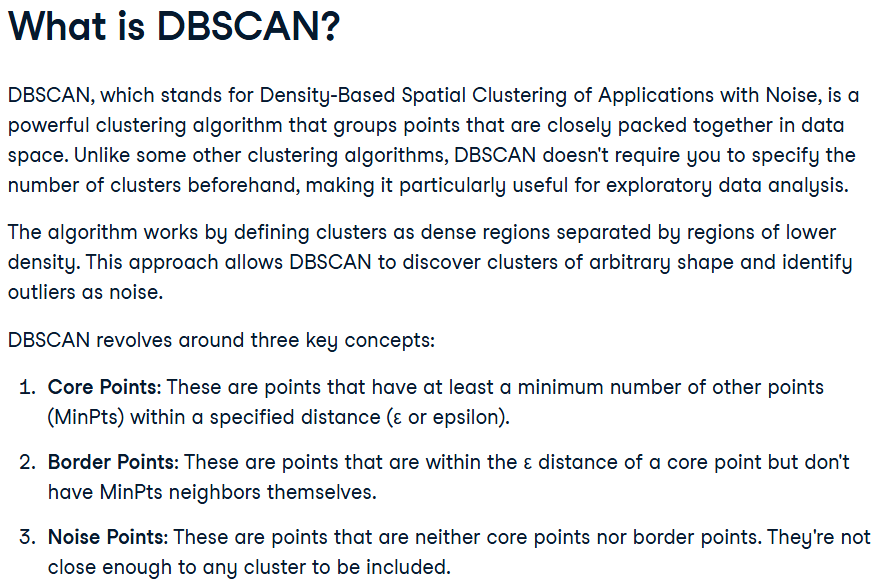

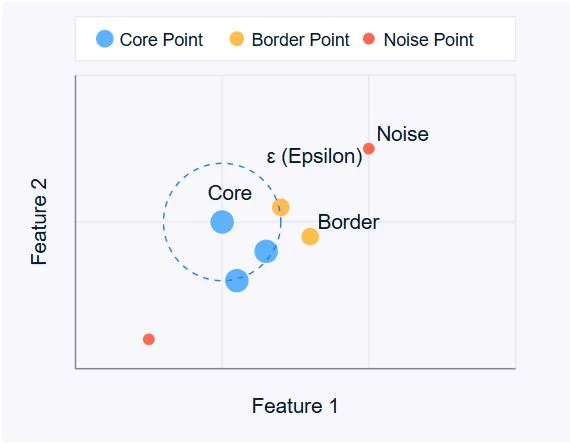


---

### **1. Core Definitions and Mathematical Framework**
DBSCAN operates on a **point cloud** $ X = \{x_1, x_2, ..., x_n\} $ in a $ d $-dimensional space $ \mathbb{R}^d $. The algorithm relies on two hyperparameters:
- **ε (epsilon)**: Radius of the neighborhood around a point.
- **MinPts**: Minimum number of points required to form a dense region.

#### **Key Concepts**
#### **a. ε-Neighborhood (N_ε(p))**
For a point $ p \in X $, the ε-neighborhood is defined as:
$$
N_\epsilon(p) = \{q \in X \mid \text{dist}(p, q) \leq \epsilon\}
$$
where $ \text{dist}(p, q) $ is a distance metric (e.g., Euclidean, Manhattan).

#### **b. Core Point**
A point $ p $ is a **core point** if:
$$
|N_\epsilon(p)| \geq \text{MinPts}
$$
Here, $ |N_\epsilon(p)| $ denotes the cardinality (number of points) in $ N_\epsilon(p) $.

#### **c. Border Point**
A point $ q $ is a **border point** if:
- $ q \in N_\epsilon(p) $ for some core point $ p $, **but** $ |N_\epsilon(q)| < \text{MinPts} $.

#### **d. Noise Point**
A point $ r $ is **noise** if:
- It is neither a core point nor a border point.

---

### **2. Density Reachability and Connectivity**
DBSCAN defines clusters through **density-connected regions**. These concepts formalize how points are grouped.

#### **a. Direct Density Reachability**
A point $ q $ is **directly density-reachable** from $ p $ if:
1. $ p $ is a core point, and
2. $ q \in N_\epsilon(p) $.

#### **b. Density Reachability**
A point $ q $ is **density-reachable** from $ p $ if there exists a chain of points $ p_1 = p, p_2, ..., p_k = q $ such that $ p_{i+1} $ is directly density-reachable from $ p_i $ for all $ i $.

#### **c. Density Connectivity**
Two points $ p $ and $ q $ are **density-connected** if there exists a point $ o $ such that both $ p $ and $ q $ are density-reachable from $ o $.

---

### **3. Algorithmic Steps (Mathematical Formalization)**
DBSCAN partitions $ X $ into clusters and noise using the following steps:

#### **Step 1: Parameter Initialization**
- Choose $ \epsilon $ and $ \text{MinPts} $.

#### **Step 2: Neighborhood Exploration**
For each unvisited point $ p \in X $:
1. Compute $ N_\epsilon(p) $.
2. If $ |N_\epsilon(p)| < \text{MinPts} $, label $ p $ as noise.
3. Else, create a new cluster $ C $ and add all points in $ N_\epsilon(p) $ to $ C $.

#### **Step 3: Cluster Expansion**
For each point $ q \in C $:
1. If $ q $ is a core point, add all points in $ N_\epsilon(q) $ to $ C $.
2. Repeat recursively until no more points can be added to $ C $.

#### **Step 4: Termination**
Repeat until all points are visited.

---

### **4. Mathematical Illustration of Clustering**
Let’s formalize the clustering process for a dataset $ X \subset \mathbb{R}^2 $.

#### **Example Dataset**
Suppose $ X $ contains 200 points sampled from two interleaving half-moons with Gaussian noise.

#### **Cluster Formation**
1. Let $ \epsilon = 0.15 $, $ \text{MinPts} = 5 $.
2. For a core point $ p $, $ N_\epsilon(p) $ contains $ \geq 5 $ points.
3. Points in $ N_\epsilon(p) $ are added to the cluster $ C $.
4. Recursively expand $ C $ by checking all points in $ N_\epsilon(q) $ for $ q \in C $.

#### **Noise Detection**
Points with $ |N_\epsilon(p)| < 5 $ are labeled as noise (e.g., outliers in sparse regions).

---

### **5. Parameter Selection: k-Distance Graph**
The choice of $ \epsilon $ is critical. The **k-distance graph** helps select $ \epsilon $:
1. For each point $ p $, compute the distance to its $ k $-th nearest neighbor (where $ k = \text{MinPts} $).
2. Sort these distances in ascending order.
3. Plot the sorted distances. The "elbow" point corresponds to an optimal $ \epsilon $.

#### **Mathematical Justification**
Let $ d_k(p) $ be the distance from $ p $ to its $ k $-th nearest neighbor. The k-distance graph plots:
$$
\text{Sorted } \{d_k(p) \mid p \in X\} \quad \text{vs. } p
$$
The elbow occurs where the rate of change of $ d_k(p) $ decreases sharply, indicating a transition from dense to sparse regions.

---

### **6. Computational Complexity**
- **Time Complexity**: $ O(n \log n) $ with spatial indexing (e.g., k-d trees), $ O(n^2) $ without.
- **Space Complexity**: $ O(n) $ for storing neighborhoods.

---

### **7. Limitations and Mathematical Insights**
#### **a. Curse of Dimensionality**
In high-dimensional spaces ($ d \gg 1 $), distances between points become less discriminative. For example, the ratio of the maximum to minimum distance converges to 1:
$$
\lim_{d \to \infty} \frac{\max_{i,j} \text{dist}(x_i, x_j)}{\min_{i,j} \text{dist}(x_i, x_j)} \to 1
$$
This makes $ \epsilon $-neighborhoods less meaningful.

#### **b. Varying Densities**
DBSCAN struggles when clusters have vastly different densities. For example:
- A dense cluster requires small $ \epsilon $, but this may split sparse clusters.
- A large $ \epsilon $ may merge dense clusters.

#### **c. Non-Convex Clusters**
DBSCAN excels at non-convex shapes because it relies on density connectivity rather than centroid proximity.

---

### **8. Comparison with K-Means**
| **Aspect**               | **DBSCAN**                                | **K-Means**                              |
|--------------------------|-------------------------------------------|------------------------------------------|
| **Cluster Shape**        | Arbitrary (density-connected regions)       | Spherical (Voronoi diagrams)             |
| **Parameter Sensitivity**| $ \epsilon $, $ \text{MinPts} $         | Number of clusters $ K $                |
| **Outliers**             | Explicitly identified as noise            | Forced into clusters                     |
| **Scalability**          | $ O(n^2) $ worst-case                     | $ O(nKd) $ per iteration                |

---

### **9. Practical Example: Moon Dataset**
Given $ X \subset \mathbb{R}^2 $ (moon-shaped data):
1. Compute $ N_\epsilon(p) $ for all $ p $.
2. Core points form the backbone of clusters.
3. Border points extend clusters to their boundaries.
4. Noise points remain unclustered.

#### **Mathematical Visualization**
For a core point $ p $, its neighborhood $ N_\epsilon(p) $ overlaps with neighboring core points, forming a connected region:
$$
C = \bigcup_{p \in \text{core}} N_\epsilon(p)
$$
Clusters are the maximal sets of density-connected points.

---

### **10. Conclusion**
DBSCAN is rooted in **topological density estimation** and **graph connectivity** principles. Its ability to discover arbitrary-shaped clusters and handle noise stems from its reliance on local density thresholds. However, its sensitivity to $ \epsilon $ and $ \text{MinPts} $, coupled with challenges in high-dimensional spaces, highlights the importance of domain knowledge and parameter tuning.



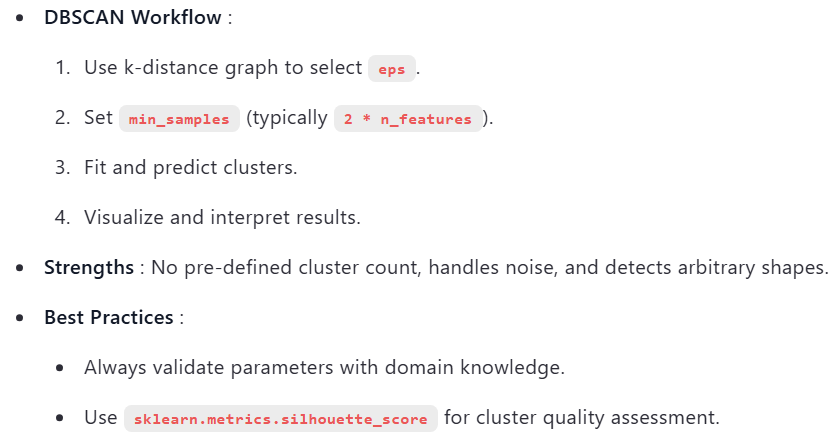

In [2]:
from sklearn.cluster import DBSCAN
import numpy as np

# Example GPS coordinates (lat, lon)
coords = np.array([[40.71, -74.01], [40.72, -74.00], [40.70, -73.99]])

# Cluster using DBSCAN
db = DBSCAN(eps=0.1, min_samples=3).fit(coords)
labels = db.labels_  # -1 = noise, others = cluster IDs

In [3]:
# Example: User spend vs. visit frequency
X = np.array([[100, 5], [200, 3], [50, 1]])
db = DBSCAN(eps=50, min_samples=2).fit(X)

In [4]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.5, min_samples=5).fit(X)
labels = db.labels_

In [5]:
labels

array([-1, -1, -1])

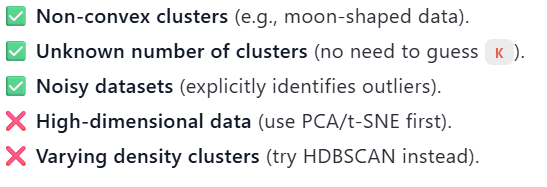